This notebook prepares transcriptomic representations for evaluating cross-donor generalization in cell-type annotation using healthy control PBMCs from the Stephenson et al. 2021 dataset. We filter to healthy donors, downsample to 500 cells per donor, and generate four representations: HVG log-normalized expression, PCA, Harmony-corrected PCs, and scVI embeddings. These representations will be used to benchmark cell-type classification under random cell-level splits versus donor-held-out splits.

In [3]:
# Data handling
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
import pertpy as pt

# Integration methods
import harmonypy as hm
import scvi

# File handling
from pathlib import Path
import os

/opt/anaconda3/envs/scanpy_pertpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Read in Data (Run either of the Blocks)**

In [ ]:
adata = pt.data.stephenson_2021_subsampled()

In [136]:
adata = ad.read_h5ad("/users/carolli/downloads/PBMC_COVID.subsample500cells.design.query_PC_refA.minimal.h5ad") # for local loads, if pertpy does not work

In [137]:
# Get current folder and create results directory
current_dir = Path.cwd()
figures_dir = current_dir / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Current directory: {current_dir}")
print(f"Figures saved to: {figures_dir}")

Current directory: /Users/carolli/Desktop/Systems Pharmacology/Final Project
Figures saved to: /Users/carolli/Desktop/Systems Pharmacology/Final Project/results/figures


**Filter Data to Control Samples, 500 Cells Each**

In [138]:
# RE-USE this script in all notebooks
# focus on healthy control samples only - in the dataset, this is the "Healthy" classification in "status" column (exclues COVID and LPS samples)
# in addition, each sample should only contain 500 cells for fairness in comparison across donors
adata_ctrl = adata[adata.obs["Status"] == "Healthy"].copy()

# downsample to 500 cells per donor if there are more than 500 cells for that donor, otherwise keep all cells for that donor
cells_to_keep = []

# Set global seed
np.random.seed(42)

for donor, idx in adata_ctrl.obs.groupby("patient_id", observed=True).groups.items():
    idx = np.array(list(idx))
    
    if len(idx) > 500:
        cells_to_keep.extend(np.random.choice(idx, 500, replace=False))
    else:
        cells_to_keep.extend(idx)

adata_ctrl = adata_ctrl[cells_to_keep].copy()

print("Control cells:", adata_ctrl.n_obs)
print("Control donors:", adata_ctrl.obs["patient_id"].nunique())

Control cells: 11290
Control donors: 23


**Normalize + Log Transform**

In [139]:
# Check the range of values in adata_ctrl.X
print(f"Min value: {adata_ctrl.X.min()}")
print(f"Max value: {adata_ctrl.X.max()}")
print(f"Mean value: {adata_ctrl.X.mean()}")

Min value: 0.0
Max value: 7.610828399658203
Mean value: 0.0767652839422226


In [140]:
# Check total counts per cell
total_counts = np.array(adata_ctrl.X.sum(axis=1)).flatten()
print(f"Total counts per cell - Min: {total_counts.min():.2f}, Max: {total_counts.max():.2f}")
print(f"Mean: {total_counts.mean():.2f}, Std: {total_counts.std():.2f}")

Total counts per cell - Min: 593.39, Max: 1871.05
Mean: 1251.20, Std: 166.32


Data already log-transformed and normalized, skipping these steps.

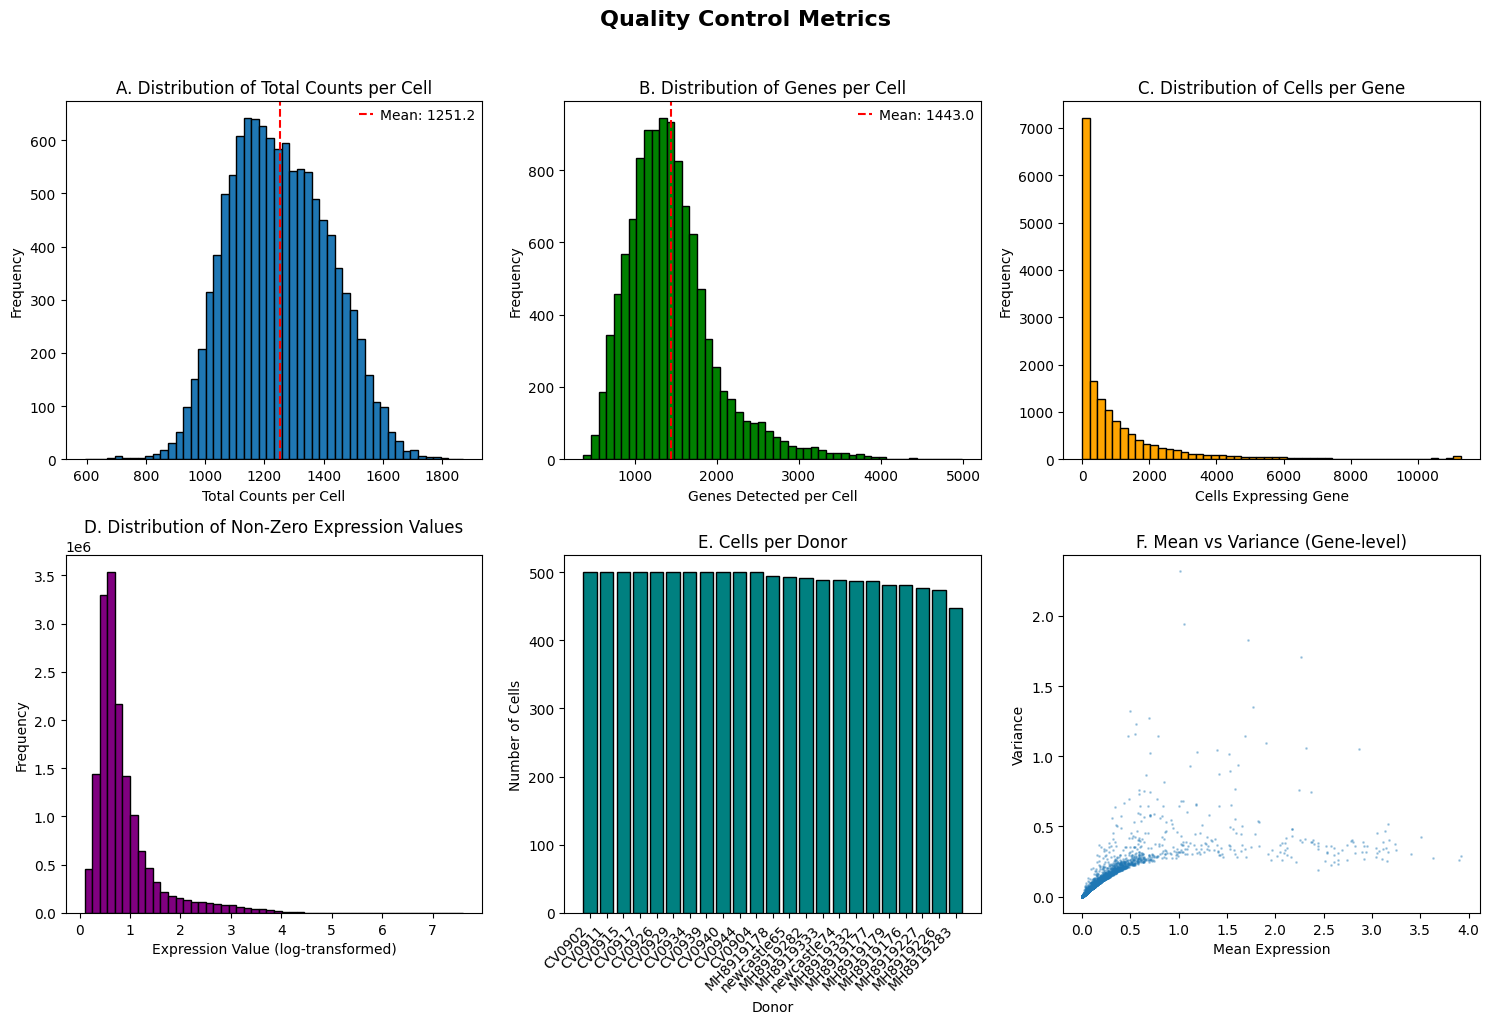


Saved: /Users/carolli/Desktop/Systems Pharmacology/Final Project/results/figures/figure2_qc_metrics.png


In [141]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Add main title
fig.suptitle('Quality Control Metrics', fontsize=16, fontweight='bold', y=1.02)

# 1a. Total counts per cell
total_counts = np.array(adata_ctrl.X.sum(axis=1)).flatten()
axes[0, 0].hist(total_counts, bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Total Counts per Cell')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('A. Distribution of Total Counts per Cell')
axes[0, 0].axvline(np.mean(total_counts), color='red', linestyle='--', label=f'Mean: {np.mean(total_counts):.1f}')
axes[0, 0].legend()

# 1b. Genes detected per cell
genes_per_cell = np.array((adata_ctrl.X > 0).sum(axis=1)).flatten()
axes[0, 1].hist(genes_per_cell, bins=50, edgecolor='black', color='green')
axes[0, 1].set_xlabel('Genes Detected per Cell')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('B. Distribution of Genes per Cell')
axes[0, 1].axvline(np.mean(genes_per_cell), color='red', linestyle='--', label=f'Mean: {np.mean(genes_per_cell):.1f}')
axes[0, 1].legend()

# 1c. Cells per gene
cells_per_gene = np.array((adata_ctrl.X > 0).sum(axis=0)).flatten()
axes[0, 2].hist(cells_per_gene, bins=50, edgecolor='black', color='orange')
axes[0, 2].set_xlabel('Cells Expressing Gene')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('C. Distribution of Cells per Gene')

# 1d. Expression value distribution (sample)
sample_expr = adata_ctrl.X.toarray().flatten() if hasattr(adata_ctrl.X, 'toarray') else adata_ctrl.X.flatten()
sample_expr = sample_expr[sample_expr > 0]  # Non-zero values only
axes[1, 0].hist(sample_expr, bins=50, edgecolor='black', color='purple')
axes[1, 0].set_xlabel('Expression Value (log-transformed)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('D. Distribution of Non-Zero Expression Values')

# 1e. Cells per donor
donor_counts = adata_ctrl.obs['patient_id'].value_counts()
axes[1, 1].bar(range(len(donor_counts)), donor_counts.values, edgecolor='black', color='teal')
axes[1, 1].set_xlabel('Donor')
axes[1, 1].set_ylabel('Number of Cells')
axes[1, 1].set_title('E. Cells per Donor')
axes[1, 1].set_xticks(range(len(donor_counts)))
axes[1, 1].set_xticklabels(donor_counts.index, rotation=45, ha='right')

# 1f. Mean expression vs variance (for HVG intuition)
mean_expr = np.array(adata_ctrl.X.mean(axis=0)).flatten()
var_expr = np.array(adata_ctrl.X.toarray().var(axis=0)).flatten() if hasattr(adata_ctrl.X, 'toarray') else np.array(adata_ctrl.X.var(axis=0)).flatten()
axes[1, 2].scatter(mean_expr, var_expr, alpha=0.3, s=1)
axes[1, 2].set_xlabel('Mean Expression')
axes[1, 2].set_ylabel('Variance')
axes[1, 2].set_title('F. Mean vs Variance (Gene-level)')

plt.tight_layout()
plt.savefig(figures_dir / 'qc_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {figures_dir / 'figure2_qc_metrics.png'}")

**Find Highly Variable Genes**

In [142]:
sc.pp.highly_variable_genes(adata_ctrl, n_top_genes=2000, batch_key="patient_id")

print(f"Number of HVGs: {adata_ctrl.var['highly_variable'].sum()}")

Number of HVGs: 2000


In [143]:
# Store Full Data in .raw before Subsetting
adata_ctrl.raw = adata_ctrl.copy()
print(f"Stored raw data shape: {adata_ctrl.raw.X.shape}")

Stored raw data shape: (11290, 16299)


In [144]:
# Subset to HVGs Only
adata_ctrl = adata_ctrl[:, adata_ctrl.var['highly_variable']].copy()
print(f"Shape after HVG subsetting: {adata_ctrl.shape}")

Shape after HVG subsetting: (11290, 2000)


**Compute PCA**

In [145]:
sc.tl.pca(adata_ctrl, n_comps=50)
print(f"\nPCA complete: {adata_ctrl.obsm['X_pca'].shape}")


PCA complete: (11290, 50)


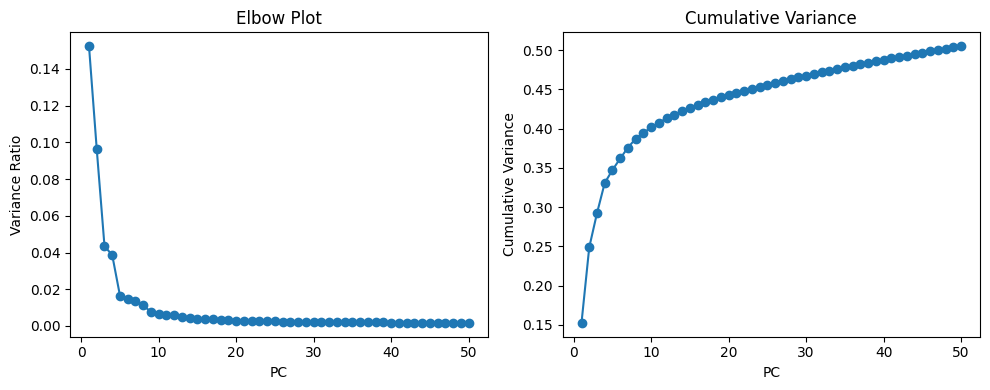

In [146]:
# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

variance_ratio = adata_ctrl.uns['pca']['variance_ratio']
cumulative_var = np.cumsum(variance_ratio)

axes[0].plot(range(1, 51), variance_ratio, 'o-')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_title('Elbow Plot')

axes[1].plot(range(1, 51), cumulative_var, 'o-')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')

plt.tight_layout()
plt.savefig(figures_dir / 'elbow_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [147]:
# Keep only first 5 PCs
adata_ctrl.obsm['X_pca'] = adata_ctrl.obsm['X_pca'][:, :5]

print(f"PCA shape: {adata_ctrl.obsm['X_pca'].shape}")

PCA shape: (11290, 5)


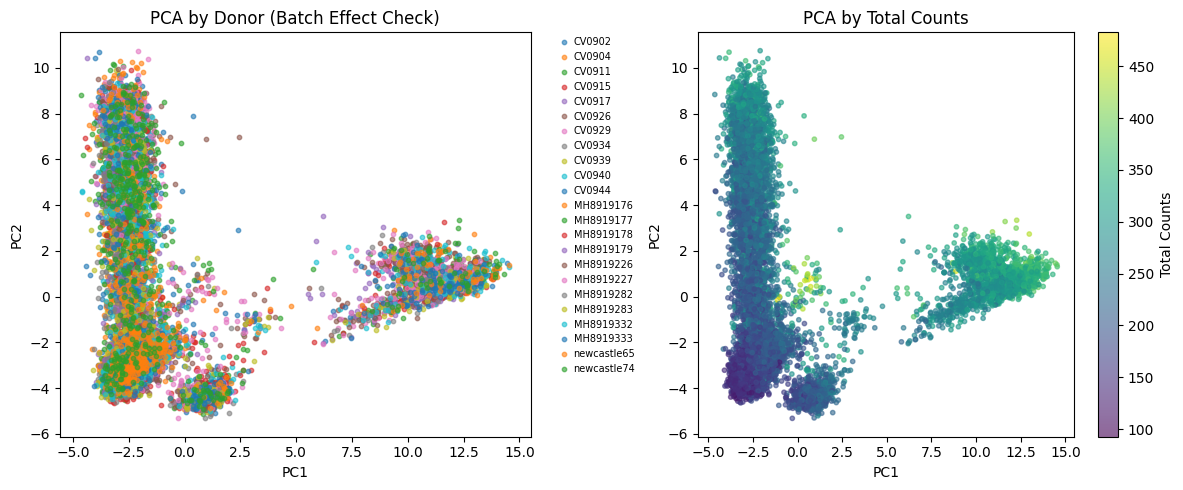

In [148]:
# PCA Sanity Check Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. PC1 vs PC2 by donor (batch effect check)
for donor in adata_ctrl.obs['patient_id'].unique():
    mask = adata_ctrl.obs['patient_id'] == donor
    axes[0].scatter(
        adata_ctrl.obsm['X_pca'][mask, 0],
        adata_ctrl.obsm['X_pca'][mask, 1],
        label=donor, alpha=0.6, s=10
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA by Donor (Batch Effect Check)')
axes[0].legend(bbox_to_anchor=(1.05, 1), fontsize=7)

# 2. PC1 vs PC2 by total counts (technical artifact check)
scatter = axes[1].scatter(
    adata_ctrl.obsm['X_pca'][:, 0],
    adata_ctrl.obsm['X_pca'][:, 1],
    c=np.array(adata_ctrl.X.sum(axis=1)).flatten(),
    cmap='viridis', alpha=0.6, s=10
)
plt.colorbar(scatter, ax=axes[1], label='Total Counts')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA by Total Counts')

plt.tight_layout()
plt.savefig(figures_dir / 'PCA_batcheffect.png', dpi=300, bbox_inches='tight')
plt.show()

**Run Harmony**

In [149]:
# Re-run PCA (need full matrix for Harmony)
sc.tl.pca(adata_ctrl, n_comps=50)

# Run Harmony
ho = hm.run_harmony(
    adata_ctrl.obsm['X_pca'],
    adata_ctrl.obs,
    'patient_id'
)

# Store result (note: Z_corr needs transpose)
adata_ctrl.obsm['X_harmony'] = ho.Z_corr

2026-03-26 15:16:36,043 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-03-26 15:16:36 | [INFO] Running Harmony (PyTorch on mps)
2026-03-26 15:16:36,044 - harmonypy - INFO -   Parameters:
2026-03-26 15:16:36 | [INFO]   Parameters:
2026-03-26 15:16:36,046 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-26 15:16:36 | [INFO]     max_iter_harmony: 10
2026-03-26 15:16:36,048 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-26 15:16:36 | [INFO]     max_iter_kmeans: 20
2026-03-26 15:16:36,049 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-26 15:16:36 | [INFO]     epsilon_cluster: 1e-05
2026-03-26 15:16:36,050 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-26 15:16:36 | [INFO]     epsilon_harmony: 0.0001
2026-03-26 15:16:36,052 - harmonypy - INFO -     nclust: 100
2026-03-26 15:16:36 | [INFO]     nclust: 100
2026-03-26 15:16:36,053 - harmonypy - INFO -     block_size: 0.05
2026-03-26 15:16:36 | [INFO]     block_size: 0.05
2026-03-26 15:16:36,057 - harmon

In [150]:
# Subset both to 5 PCs
adata_ctrl.obsm['X_pca'] = adata_ctrl.obsm['X_pca'][:, :5]
adata_ctrl.obsm['X_harmony'] = adata_ctrl.obsm['X_harmony'][:, :5]

print(f"PCA shape: {adata_ctrl.obsm['X_pca'].shape}")
print(f"Harmony shape: {adata_ctrl.obsm['X_harmony'].shape}")

PCA shape: (11290, 5)
Harmony shape: (11290, 5)


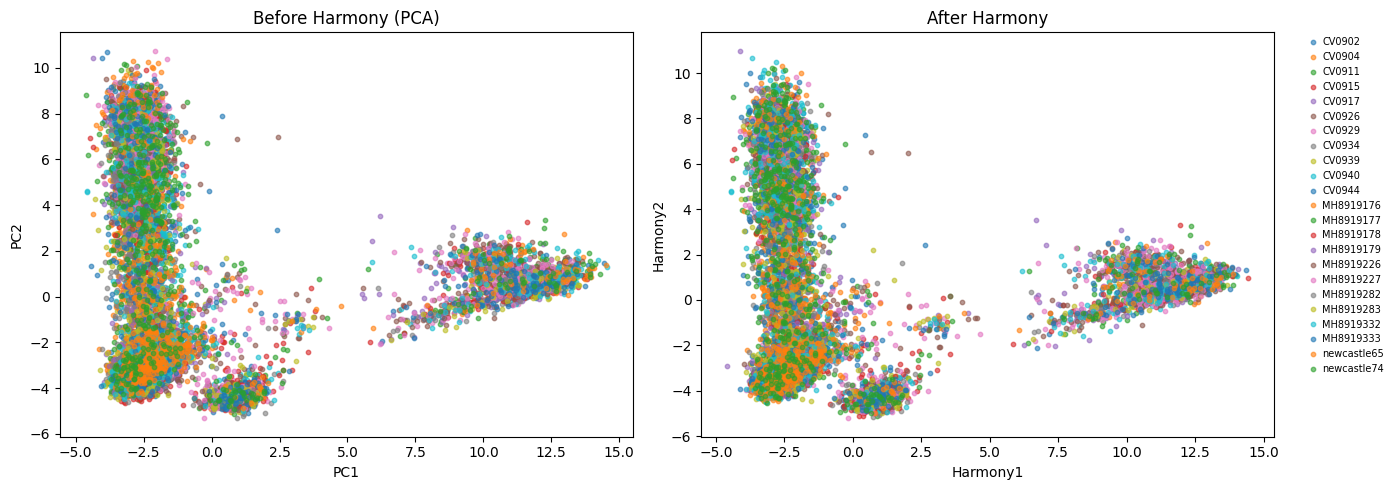

In [151]:
# Before vs After Harmony
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before (PCA)
for donor in adata_ctrl.obs['patient_id'].unique():
    mask = adata_ctrl.obs['patient_id'] == donor
    axes[0].scatter(
        adata_ctrl.obsm['X_pca'][mask, 0],
        adata_ctrl.obsm['X_pca'][mask, 1],
        label=donor, alpha=0.6, s=10
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Before Harmony (PCA)')

# After (Harmony)
for donor in adata_ctrl.obs['patient_id'].unique():
    mask = adata_ctrl.obs['patient_id'] == donor
    axes[1].scatter(
        adata_ctrl.obsm['X_harmony'][mask, 0],
        adata_ctrl.obsm['X_harmony'][mask, 1],
        label=donor, alpha=0.6, s=10
    )
axes[1].set_xlabel('Harmony1')
axes[1].set_ylabel('Harmony2')
axes[1].set_title('After Harmony')
axes[1].legend(bbox_to_anchor=(1.05, 1), fontsize=7)

plt.tight_layout()
plt.savefig(figures_dir / 'harmonry_effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [152]:
# Silhouette Score (lower = better mixing)
from sklearn.metrics import silhouette_score

# Before Harmony
sil_before = silhouette_score(
    adata_ctrl.obsm['X_pca'],
    adata_ctrl.obs['patient_id']
)

# After Harmony
sil_after = silhouette_score(
    adata_ctrl.obsm['X_harmony'],
    adata_ctrl.obs['patient_id']
)

print(f"Silhouette Score (by donor):")
print(f"  Before Harmony: {sil_before:.4f}")
print(f"  After Harmony:  {sil_after:.4f}")
print(f"  (Lower = better mixing of donors)")

Silhouette Score (by donor):
  Before Harmony: -0.1857
  After Harmony:  -0.2005
  (Lower = better mixing of donors)


In [153]:
# Batch Entropy (higher = better mixing)
from sklearn.neighbors import NearestNeighbors

def batch_entropy(X, labels, n_neighbors=50):
    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X)
    indices = nn.kneighbors(return_distance=False)
    
    entropies = []
    for i, neighbors in enumerate(indices):
        neighbor_labels = labels[neighbors]
        _, counts = np.unique(neighbor_labels, return_counts=True)
        probs = counts / counts.sum()
        entropy = -np.sum(probs * np.log(probs + 1e-10))
        entropies.append(entropy)
    
    return np.mean(entropies)

labels = adata_ctrl.obs['patient_id'].values

ent_before = batch_entropy(adata_ctrl.obsm['X_pca'], labels)
ent_after = batch_entropy(adata_ctrl.obsm['X_harmony'], labels)

print(f"Batch Entropy:")
print(f"  Before Harmony: {ent_before:.4f}")
print(f"  After Harmony:  {ent_after:.4f}")
print(f"  (Higher = better mixing of donors)")

Batch Entropy:
  Before Harmony: 2.4158
  After Harmony:  2.6488
  (Higher = better mixing of donors)


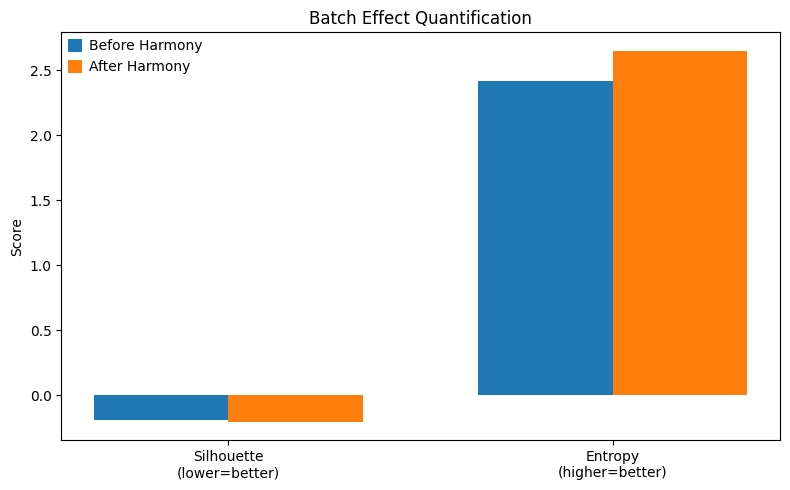

In [154]:
# Summary plot
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ['Silhouette\n(lower=better)', 'Entropy\n(higher=better)']
before = [sil_before, ent_before]
after = [sil_after, ent_after]

x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, before, width, label='Before Harmony')
ax.bar(x + width/2, after, width, label='After Harmony')

ax.set_ylabel('Score')
ax.set_title('Batch Effect Quantification')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / 'Batch_quantified.png', dpi=300, bbox_inches='tight')
plt.show()

**Extract scVI embeddings from processed data**

In [155]:
adata_ctrl.obsm

AxisArrays with keys: X_scVI, X_umap, X_pca, X_harmony

scVI embeddings already exist in the original dataset.

**Sanity checks and plots generation**

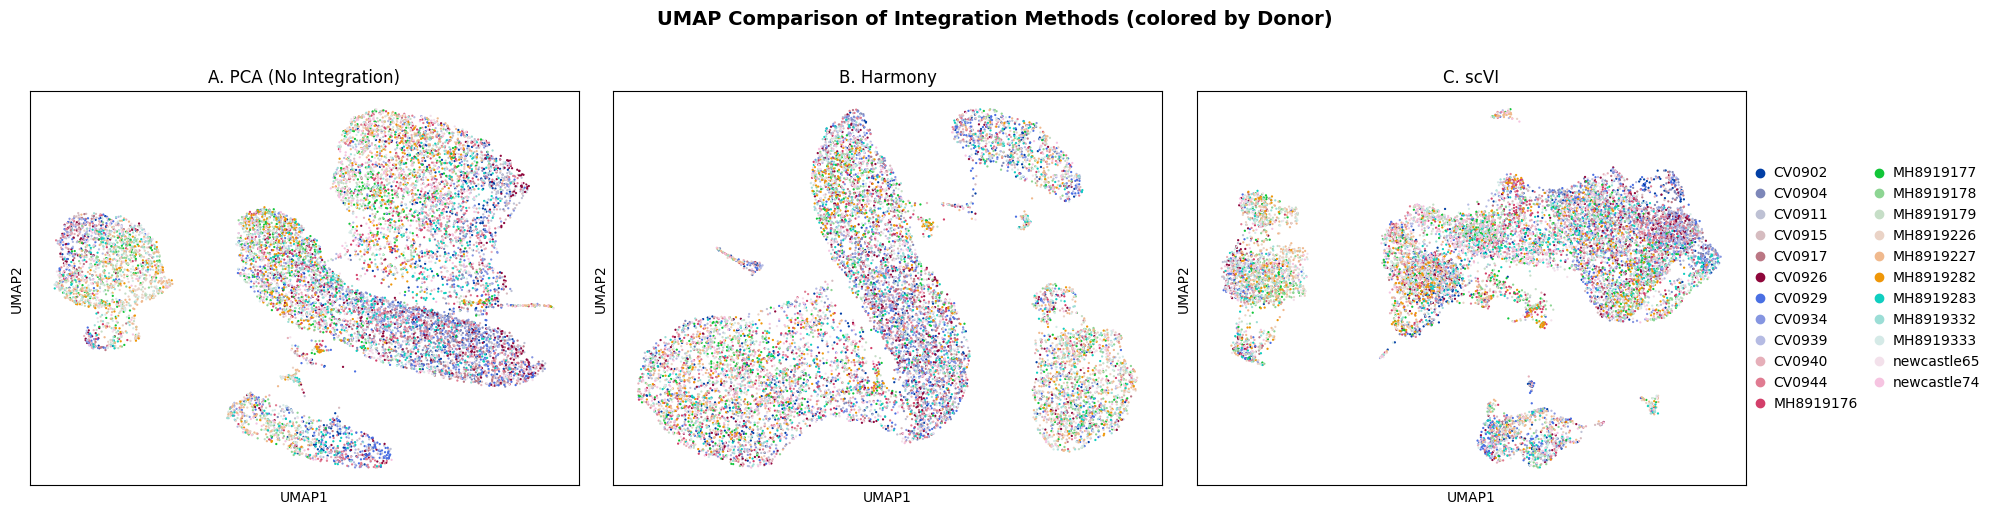


Saved: /Users/carolli/Desktop/Systems Pharmacology/Final Project/results/figures/umap_comparison.png


In [156]:
# Compute UMAPs on the copy
# PCA
sc.pp.neighbors(adata_ctrl, use_rep="X_pca", key_added="pca_neighbors")
sc.tl.umap(adata_ctrl, neighbors_key="pca_neighbors")
adata_ctrl.obsm["X_umap_pca"] = adata_ctrl.obsm["X_umap"].copy()

# Harmony
sc.pp.neighbors(adata_ctrl, use_rep="X_harmony", key_added="harmony_neighbors")
sc.tl.umap(adata_ctrl, neighbors_key="harmony_neighbors")
adata_ctrl.obsm["X_umap_harmony"] = adata_ctrl.obsm["X_umap"].copy()

# scVI
sc.pp.neighbors(adata_ctrl, use_rep="X_scVI", key_added="scvi_neighbors")
sc.tl.umap(adata_ctrl, neighbors_key="scvi_neighbors")
adata_ctrl.obsm["X_umap_scvi"] = adata_ctrl.obsm["X_umap"].copy()

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Add main title
fig.suptitle('UMAP Comparison of Integration Methods (colored by Donor)', 
             fontsize=14, fontweight='bold', y=1.02)

adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_pca"]
sc.pl.umap(adata_ctrl, color="patient_id", ax=axes[0], show=False, title="A. PCA (No Integration)", legend_loc=None)

adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_harmony"]
sc.pl.umap(adata_ctrl, color="patient_id", ax=axes[1], show=False, title="B. Harmony", legend_loc=None)

adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_scvi"]
sc.pl.umap(adata_ctrl, color="patient_id", ax=axes[2], show=False, title="C. scVI")

plt.tight_layout()
plt.savefig(figures_dir / 'umap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {figures_dir / 'umap_comparison.png'}")

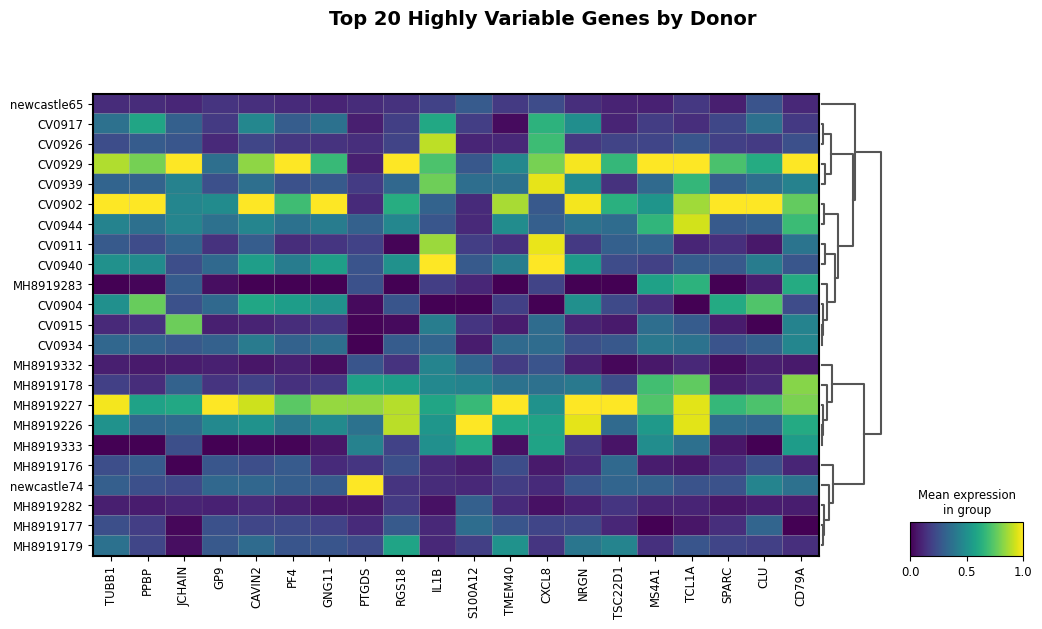


Saved: /Users/carolli/Desktop/Systems Pharmacology/Final Project/results/figures/heatmap_top_hvgs.png


In [158]:
# Heatmap of top HVGs by variance - aggregated by patient
top_genes = adata_ctrl.var.sort_values('dispersions_norm', ascending=False).head(20).index

sc.pl.matrixplot(
    adata_ctrl,
    var_names=top_genes,
    groupby='patient_id',
    cmap='viridis',
    standard_scale='var',  # Scale each gene 0-1
    dendrogram=True,
    figsize=(12, 6),
    show=False
)

# Get current figure and add title
fig = plt.gcf()
fig.suptitle('Top 20 Highly Variable Genes by Donor', 
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig(figures_dir / 'heatmap_top_hvgs.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {figures_dir / 'heatmap_top_hvgs.png'}")

/var/folders/4v/q4dp699j72z5_vq3f8vkdpn40000gn/T/ipykernel_81917/13357254.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_site = adata_ctrl.obs.groupby('patient_id')['Site'].first()
/var/folders/4v/q4dp699j72z5_vq3f8vkdpn40000gn/T/ipykernel_81917/13357254.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle


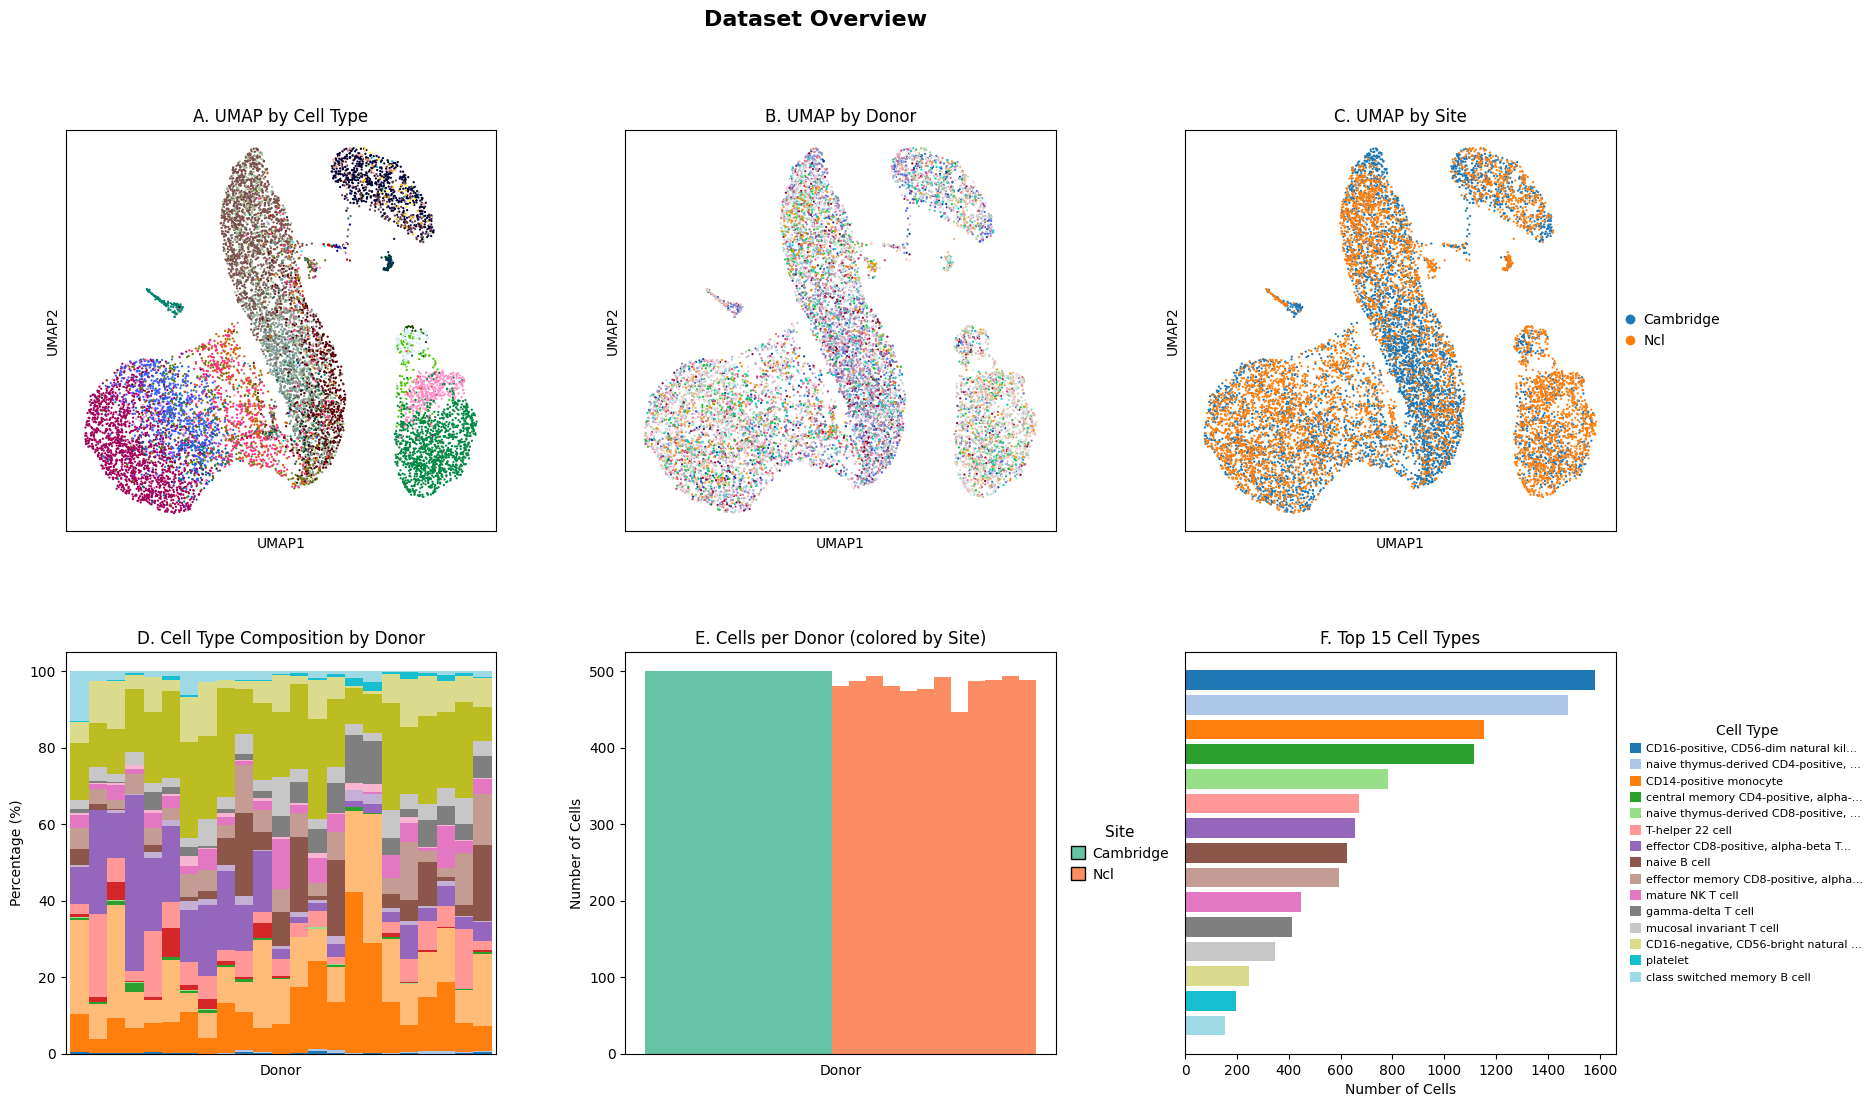


Saved: /Users/carolli/Desktop/Systems Pharmacology/Final Project/results/figures/dataset_overview.png


In [159]:
# Create Dataset Overview Figure
fig = plt.figure(figsize=(20, 12))

# Add overall title
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold', y=0.98)

# Define grid: 2 rows, custom column widths
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3, width_ratios=[1, 1, 1])

# Use one of the integrated representations for UMAP
adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_harmony"]

# ------ Row 1 ------

# 1A: UMAP by cell type
ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(adata_ctrl, color="cell_type", ax=ax1, show=False, 
           title="A. UMAP by Cell Type", frameon=True, legend_loc=None)

# 1B: UMAP by donor
ax2 = fig.add_subplot(gs[0, 1])
sc.pl.umap(adata_ctrl, color="patient_id", ax=ax2, show=False, 
           title="B. UMAP by Donor", frameon=True, legend_loc=None)

# 1C: UMAP by site
ax3 = fig.add_subplot(gs[0, 2])
sc.pl.umap(adata_ctrl, color="Site", ax=ax3, show=False, 
           title="C. UMAP by Site", frameon=True)

# ------ Row 2 ------

# 1D: Cell type composition per donor
ax4 = fig.add_subplot(gs[1, 0])
composition = pd.crosstab(adata_ctrl.obs['patient_id'], 
                          adata_ctrl.obs['cell_type'], 
                          normalize='index') * 100
composition.plot(kind='bar', stacked=True, ax=ax4, 
                 colormap='tab20', edgecolor='none', width=1.0, legend=False)
ax4.set_xlabel('Donor')
ax4.set_ylabel('Percentage (%)')
ax4.set_title('D. Cell Type Composition by Donor')
ax4.set_xticklabels([])
ax4.tick_params(axis='x', length=0)

# 1E: Cells per donor, colored by site
ax5 = fig.add_subplot(gs[1, 1])
donor_site = adata_ctrl.obs.groupby('patient_id')['Site'].first()
donor_counts = adata_ctrl.obs['patient_id'].value_counts().sort_index()

sites = donor_site.unique()
site_colors = dict(zip(sites, plt.cm.Set2.colors[:len(sites)]))
bar_colors = [site_colors[donor_site[donor]] for donor in donor_counts.index]

ax5.bar(range(len(donor_counts)), donor_counts.values, color=bar_colors, edgecolor='none', width=1.0)
ax5.set_xlabel('Donor')
ax5.set_ylabel('Number of Cells')
ax5.set_title('E. Cells per Donor (colored by Site)')
ax5.set_xticklabels([])
ax5.tick_params(axis='x', length=0)

# Legend on right
from matplotlib.patches import Patch
site_legend = [Patch(facecolor=site_colors[s], edgecolor='black', label=s) for s in sites]
ax5.legend(handles=site_legend, 
           loc='center left', 
           bbox_to_anchor=(1.02, 0.5),
           fontsize=10,
           frameon=False,
           title='Site',
           title_fontsize=11)

# 1F: Cell type abundance
ax6 = fig.add_subplot(gs[1, 2])
celltype_counts = adata_ctrl.obs['cell_type'].value_counts().head(15)
colors_ct = plt.cm.tab20(np.linspace(0, 1, len(celltype_counts)))

bars = ax6.barh(range(len(celltype_counts)), celltype_counts.values, color=colors_ct, edgecolor='none')
ax6.set_yticks([])
ax6.set_xlabel('Number of Cells')
ax6.set_title('F. Top 15 Cell Types')
ax6.invert_yaxis()

# Add legend to the right
short_names = [name[:35] + '...' if len(name) > 35 else name for name in celltype_counts.index]
ax6.legend(bars, short_names, loc='center left', bbox_to_anchor=(1.02, 0.5), 
           fontsize=8, title='Cell Type', frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
plt.savefig(figures_dir / 'dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {figures_dir / 'dataset_overview.png'}")

In [160]:
adata_ctrl

AnnData object with n_obs × n_vars = 11290 × 2000
    obs: 'Collection_Day', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'author_cell_type', 'organism', 'sex', 'tissue', 'ethnicity', 'disease', 'assay', 'cell_type', 'dataset_group'
    var: 'gene_id', 'gene_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'umap', 'hvg', 'pca', 'pca_neighbors', 'harmony_neighbors', 'scvi_neighbors', 'patient_id_colors', 'dendrogram_patient_id', 'cell_type_colors', 'Site_colors'
    obsm: 'X_scVI', 'X_umap', 'X_pca', 'X_harmony', 'X_umap_pca', 'X_umap_harmony', 'X_umap_scvi'
    varm: 'PCs'
    obsp: 'pca_neighbors_distances', 'pca_neighbors_connectivities', 'harmony_neighbors_distances', 'harmony_neighbors_connectivities', 'scvi_neighbors_distances', 'scvi_nei

In [162]:
print("=== Verifying Representations for Classification ===\n")

# Check HVG expression
print(f"✓ adata.X (HVG expression): {adata_ctrl.X.shape}")

# Check raw expression
if adata_ctrl.raw is not None:
    print(f"✓ adata.raw.X (full expression): {adata_ctrl.raw.X.shape}")
else:
    print("✗ adata.raw is missing!")

# Check embeddings
embeddings = ['X_pca', 'X_harmony', 'X_scVI']
for emb in embeddings:
    if emb in adata_ctrl.obsm:
        print(f"✓ adata.obsm['{emb}']: {adata_ctrl.obsm[emb].shape}")
    else:
        print(f"✗ adata.obsm['{emb}'] is missing!")

# Check metadata
print(f"\n=== Metadata ===")
print(f"✓ Cell types: {adata_ctrl.obs['cell_type'].nunique()} unique")
print(f"✓ Donors: {adata_ctrl.obs['patient_id'].nunique()} unique")
print(f"✓ Total cells: {adata_ctrl.n_obs}")

=== Verifying Representations for Classification ===

✓ adata.X (HVG expression): (11290, 2000)
✓ adata.raw.X (full expression): (11290, 16299)
✓ adata.obsm['X_pca']: (11290, 5)
✓ adata.obsm['X_harmony']: (11290, 5)
✓ adata.obsm['X_scVI']: (11290, 10)

=== Metadata ===
✓ Cell types: 41 unique
✓ Donors: 23 unique
✓ Total cells: 11290


In [163]:
# Rename X_scVI to X_scvi for consistency (lowercase)
if 'X_scVI' in adata_ctrl.obsm:
    adata_ctrl.obsm['X_scvi'] = adata_ctrl.obsm['X_scVI'].copy()
    del adata_ctrl.obsm['X_scVI']
    print("Renamed X_scVI → X_scvi")

Renamed X_scVI → X_scvi


In [164]:
# Create output directory
output_dir = current_dir / 'results' / 'data'
output_dir.mkdir(parents=True, exist_ok=True)

# Save processed adata
output_file = output_dir / 'adata_processed.h5ad'
adata_ctrl.write(output_file)

print(f"\n=== Saved ===")
print(f"File: {output_file}")
print(f"Size: {output_file.stat().st_size / 1e6:.1f} MB")


=== Saved ===
File: /Users/carolli/Desktop/Systems Pharmacology/Final Project/results/data/adata_processed.h5ad
Size: 167.3 MB


In [166]:
# Verify saved file
adata_test = ad.read_h5ad(output_file)

print("=== Final Verification (reloaded file) ===\n")
print(f"adata.X (HVG expression): {adata_test.X.shape}")
print(f"adata.raw.X (full expression): {adata_test.raw.X.shape}")
print(f"adata.obsm['X_pca']: {adata_test.obsm['X_pca'].shape}")
print(f"adata.obsm['X_harmony']: {adata_test.obsm['X_harmony'].shape}")
print(f"adata.obsm['X_scvi']: {adata_test.obsm['X_scvi'].shape}")
print(f"\nCell types: {adata_test.obs['cell_type'].nunique()}")
print(f"Donors: {adata_test.obs['patient_id'].nunique()}")
print(f"\n✓ Ready for classification benchmarking")

=== Final Verification (reloaded file) ===

adata.X (HVG expression): (11290, 2000)
adata.raw.X (full expression): (11290, 16299)
adata.obsm['X_pca']: (11290, 5)
adata.obsm['X_harmony']: (11290, 5)
adata.obsm['X_scvi']: (11290, 10)

Cell types: 41
Donors: 23

✓ Ready for classification benchmarking


In [167]:
print("""
=== Data Format Summary ===

File: results/data/adata_processed.h5ad

Representations:
  - adata.X           → HVG log-normalized expression (2000 genes)
  - adata.raw.X       → Full expression before HVG subsetting
  - adata.obsm['X_pca']     → PCA (5 components)
  - adata.obsm['X_harmony'] → Harmony-corrected PCs (5 components)
  - adata.obsm['X_scvi']    → scVI latent embeddings

Metadata:
  - adata.obs['cell_type']   → Classification target
  - adata.obs['patient_id']  → Donor ID (for donor-held-out splits)
  
Dataset:
  - 11,290 cells
  - 23 healthy donors
  - ~40 cell types
""")


=== Data Format Summary ===

File: results/data/adata_processed.h5ad

Representations:
  - adata.X           → HVG log-normalized expression (2000 genes)
  - adata.raw.X       → Full expression before HVG subsetting
  - adata.obsm['X_pca']     → PCA (5 components)
  - adata.obsm['X_harmony'] → Harmony-corrected PCs (5 components)
  - adata.obsm['X_scvi']    → scVI latent embeddings

Metadata:
  - adata.obs['cell_type']   → Classification target
  - adata.obs['patient_id']  → Donor ID (for donor-held-out splits)
  
Dataset:
  - 11,290 cells
  - 23 healthy donors
  - ~40 cell types

